Q1 - Matriz & sistemas lineares

In [ ]:
#modelei o problema no caderno (tive que mudar a matriz do enunciado padrao) e aqui resolvi ele descobrindo os valores de x1,x2,x3

from numpy import *
from numpy.linalg import *

A = array([[0.15, 0.17, 0.19], [0.03, 0.04, 0.01], [0.02, 0.03, 0.02]])
b = array([[3.89], [0.095], [0.282]])

I = solve(A,b)
print("valores de x1,x2 e x3: \n", I)

valores de x1,x2 e x3: 
 [[ 19.21923077]
 [-17.21538462]
 [ 20.70384615]]


Q2 - Otimização

O valor de c onde o crescimento é maximo é de:  [1.56791058]
O crescimento fica igual a:  [0.36963485]


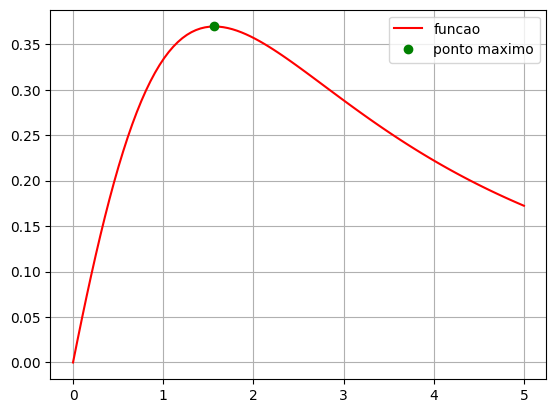

In [25]:
from scipy.optimize import * 
from matplotlib.pyplot import *
from numpy import *

def g(c):
    y = 2*c/(4 +0.8*c + c**2 + 0.2*c**3)
    return -y


x0 = 3

maximo = minimize(g, x0)
valor = maximo.x
ymaximo = -g(valor)

print("O valor de c onde o crescimento é maximo é de: ", valor)
print("O crescimento fica igual a: ", ymaximo)

xx = linspace(0, 5, 100)
plot(xx, -g(xx), 'r-', label="funcao")
plot(valor,ymaximo, 'go', label="ponto maximo" )


grid()
legend()




Q3 -  Regula falsi + secante
from matplotlib.pyplot import *
from numpy import *


secante: 0.7192051811294533


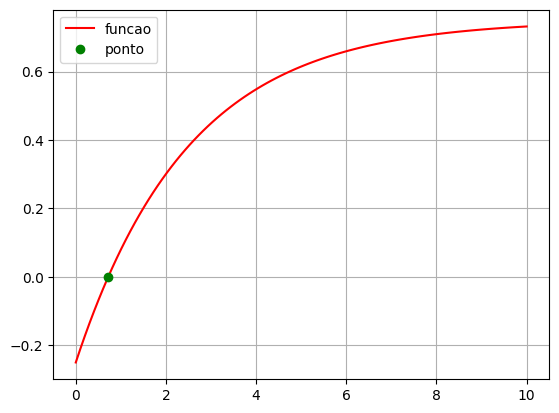

In [32]:
from scipy.optimize import * 
from matplotlib.pyplot import *
from numpy import *

#secante
def f(k):
    y = 0.75 - exp(-0.4*k)
    return y

x0 = 3

resposta = newton(f,x0)
print("secante:",resposta)


k = linspace(0,10,100)

plot(k, f(k), 'r-', label="funcao")
plot(resposta, f(resposta), 'go', label="ponto")
grid()
legend()


Q4 - Newton e lagrange

Polinomio de newton:  [ 4.000e-10 -5.160e-07  2.586e-04 -6.295e-02  7.442e+00]
Densidade de 330 graus com Newton:  1.0302320000000078
Polinomio de lagrange:         4            3             2
4e-10 x - 5.16e-07 x + 0.0002586 x - 0.06295 x + 7.442
Densidade de lagrange com 330 graus:  1.0302319999999003


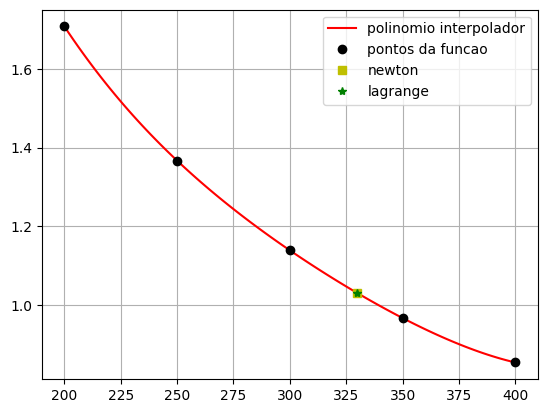

In [55]:
from matplotlib.pyplot import *
from numpy import *
from scipy.interpolate import *

T = array([200,250,300,350,400])
D = array([1.708,1.367,1.139,0.967,0.854])

k = 330

N = polyfit(T,D,4)
resposta = poly1d(N)

print("Polinomio de newton: ", N)
print("Densidade de 330 graus com Newton: ",resposta(330))



#lagrange

L = lagrange(T,D)
print("Polinomio de lagrange: ", L)
print("Densidade de lagrange com 330 graus: ", L(330))

#plotando
Tfino = linspace(200, 400, 100)
plot(Tfino, resposta(Tfino), 'r-', label="polinomio interpolador")
plot(T, D, 'ko', label="pontos da funcao")
plot(k, resposta(k), 'ys', label="newton")
plot(k, L(k), 'g*', label="lagrange")

grid()
legend()

Q5 - Simpson

simpson:  579.0
trapezio:  581.5


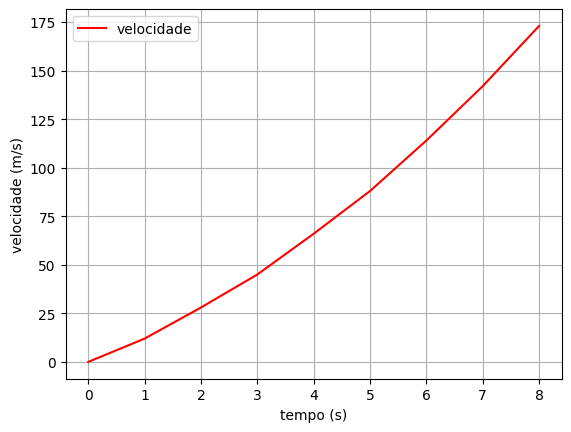

In [ ]:
from scipy.integrate import *
from matplotlib.pyplot import *
from numpy import *

T = ([0,1,2,3,4,5,6,7,8])
V = ([0,12,28,45,66,88,114,142,173])

rs = simpson(V,T)
print("simpson: ",rs)

rt = trapezoid(V,T)
print("trapezio: ", rt)

#aqui nao da pra plotar nenhum ponto nem mais nada pq n tem ponto, so o valor total de distancia
plot(T, V, 'r-', label="velocidade") 
xlabel('tempo (s)')
ylabel('velocidade (m/s)')
legend()
grid()



Q6 - EDOS

In [67]:
from matplotlib.pyplot import *
from numpy import *
from scipy.integrate import *

def D(t,c):
   y = -0.06*c + 2
   return y

t = array([0,2,4,6,8,10,12,14,16,18,20])
tt = linspace(0,20,11)

c = 10

resposta = solve_ivp(D,[0,20],[c],method='RK45', t_eval=tt)
print(resposta)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.000e+00  4.000e+00  6.000e+00  8.000e+00
             1.000e+01  1.200e+01  1.400e+01  1.600e+01  1.800e+01
             2.000e+01]
        y: [[ 1.000e+01  1.264e+01  1.498e+01  1.706e+01  1.890e+01
              2.053e+01  2.198e+01  2.326e+01  2.440e+01  2.541e+01
              2.630e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 26
     njev: 0
      nlu: 0
